In [1]:
import pandas as pd



In [2]:
df=pd.read_csv("Railway_info.csv")

In [3]:
df.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [ ]:
df.info()
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB
Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


In [6]:
num_trains = df['Train_Name'].nunique()
print("Total Unique Trains:", num_trains)

unique_sources = df['Source_Station_Name'].nunique()
print("Unique Source Stations:", unique_sources)

unique_destinations = df['Destination_Station_Name'].nunique()
print("Unique Destination Stations:", unique_destinations)

print("\nMost Common Source Station:")
print(df['Source_Station_Name'].value_counts().head(1))

print("\nMost Common Destination Station:")
print(df['Destination_Station_Name'].value_counts().head(1))


Total Unique Trains: 7580
Unique Source Stations: 921
Unique Destination Stations: 924

Most Common Source Station:
Source_Station_Name
CST-MUMBAI    513
Name: count, dtype: int64

Most Common Destination Station:
Destination_Station_Name
CST-MUMBAI    514
Name: count, dtype: int64


In [7]:

df.fillna("UNKNOWN", inplace=True)

df['Source_Station_Name'] = df['Source_Station_Name'].str.upper()
df['Destination_Station_Name'] = df['Destination_Station_Name'].str.upper()

print("Cleaning Done")


Cleaning Done


In [11]:
saturday_trains = df[df['days'].str.contains("Sat", case=False, na=False)]

print("Saturday Trains:")
print(saturday_trains.head())



Saturday Trains:
    Train_No    Train_Name Source_Station_Name Destination_Station_Name  \
0        107  SWV-MAO-VLNK     SAWANTWADI ROAD              MADGOAN JN.   
4        401  BSB BHARATDA          AURANGABAD             VARANASI JN.   
21      1196  NGP-KRMI SPL      NAGPUR JN.(CR)                  KARMALI   
28      1706   JBP-BDTS SF            JABALPUR          BANDRA TERMINUS   
45      2834  SRC-RJT SF A     SANTRAGACHI JN.                   RAJKOT   

        days  
0   Saturday  
4   Saturday  
21  Saturday  
28  Saturday  
45  Saturday  


In [12]:
jaipur_trains = df[df['Source_Station_Name'] == "JAIPUR"]
print(jaipur_trains.head())


Empty DataFrame
Columns: [Train_No, Train_Name, Source_Station_Name, Destination_Station_Name, days]
Index: []


In [13]:
trains_per_source = df.groupby('Source_Station_Name')['Train_Name'].count()
print(trains_per_source.sort_values(ascending=False))


Source_Station_Name
CST-MUMBAI        513
SEALDAH           372
CHENNAI BEACH     339
HOWRAH JN.        338
KALYAN JN         285
                 ... 
ANKLESHWAR JN.      1
VAPI                1
ACHHNERA JN.        1
ABU ROAD            1
ABOHAR              1
Name: Train_Name, Length: 921, dtype: int64


In [ ]:
df['Total_Operating_Days'] = df['days'].apply(lambda x: len(str(x).split()))

print(df[['Train_Name', 'Total_Operating_Days']].head())


     Train_Name  Total_Operating_Days
0  SWV-MAO-VLNK                     1
1  VLNK-MAO-SWV                     1
2  MAO-KOP SPEC                     1
3  PALACE ON WH                     1
4  BSB BHARATDA                     1


In [17]:
def categorize(days_value):
    days_value = str(days_value)

    if "Sat" in days_value or "Sun" in days_value or "Daily" in days_value:
        return "Weekend"
    else:
        return "Weekday"

df['Category'] = df['days'].apply(categorize)

print(df[['Train_Name','days','Category']].head())


     Train_Name       days Category
0  SWV-MAO-VLNK   Saturday  Weekend
1  VLNK-MAO-SWV     Friday  Weekday
2  MAO-KOP SPEC     Friday  Weekday
3  PALACE ON WH  Wednesday  Weekday
4  BSB BHARATDA   Saturday  Weekend


In [19]:
week_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


In [ ]:
day_counts = {}

for day in week_days:
    day_counts[day] = df['days'].str.contains(day, case=False, na=False).sum()

daily_count = df['days'].str.contains("Daily", case=False, na=False).sum()

for day in week_days:
    day_counts[day] += daily_count

print(day_counts)


{'Mon': np.int64(1503), 'Tue': np.int64(1628), 'Wed': np.int64(1612), 'Thu': np.int64(1526), 'Fri': np.int64(1649), 'Sat': np.int64(1593), 'Sun': np.int64(1602)}


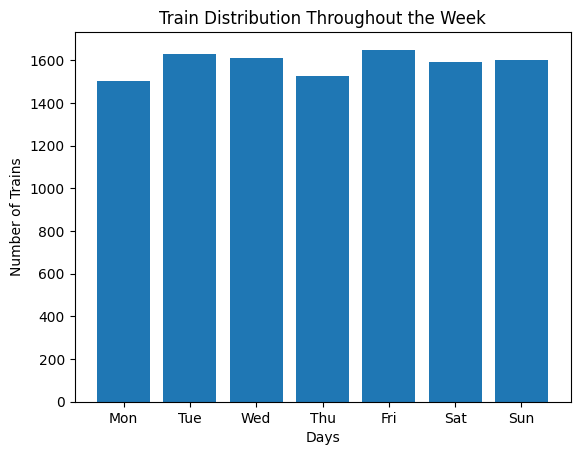

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(day_counts.keys(), day_counts.values())

plt.title("Train Distribution Throughout the Week")
plt.xlabel("Days")
plt.ylabel("Number of Trains")

plt.show()


In [ ]:
week_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for day in week_days:
    df[day] = df['days'].str.contains(day, case=False, na=False).astype(int)

daily_mask = df['days'].str.contains("Daily", case=False, na=False)

for day in week_days:
    df.loc[daily_mask, day] = 1

print(df[week_days].head())


   Mon  Tue  Wed  Thu  Fri  Sat  Sun
0    0    0    0    0    0    1    0
1    0    0    0    0    1    0    0
2    0    0    0    0    1    0    0
3    0    0    1    0    0    0    0
4    0    0    0    0    0    1    0


In [26]:
correlation = df[week_days].corr()

print("Correlation Matrix:")
print(correlation)


Correlation Matrix:
          Mon       Tue       Wed       Thu       Fri       Sat       Sun
Mon  1.000000 -0.163842 -0.162898 -0.157781 -0.165079 -0.161773 -0.162307
Tue -0.163842  1.000000 -0.170650 -0.165289 -0.172934 -0.169472 -0.170030
Wed -0.162898 -0.170650  1.000000 -0.164336 -0.171938 -0.168495 -0.169050
Thu -0.157781 -0.165289 -0.164336  1.000000 -0.166536 -0.163202 -0.163740
Fri -0.165079 -0.172934 -0.171938 -0.166536  1.000000 -0.170751 -0.171313
Sat -0.161773 -0.169472 -0.168495 -0.163202 -0.170751  1.000000 -0.167883
Sun -0.162307 -0.170030 -0.169050 -0.163740 -0.171313 -0.167883  1.000000


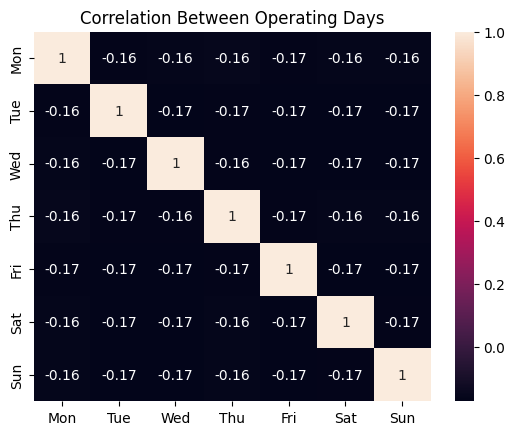

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(correlation, annot=True)

plt.title("Correlation Between Operating Days")
plt.show()


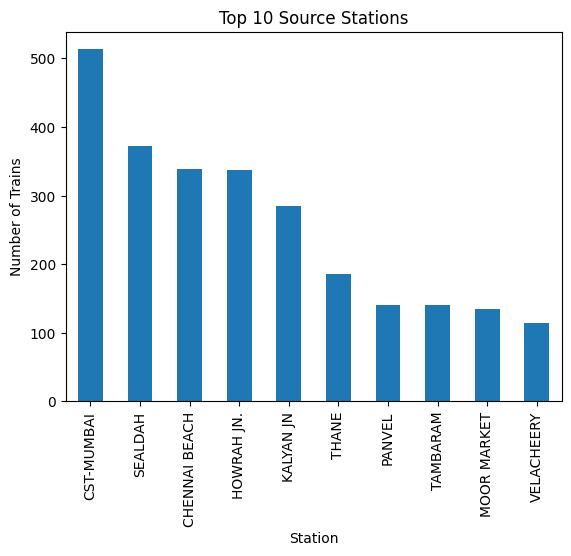

In [28]:
top_sources = df['Source_Station_Name'].value_counts().head(10)

plt.figure()
top_sources.plot(kind='bar')

plt.title("Top 10 Source Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")

plt.show()


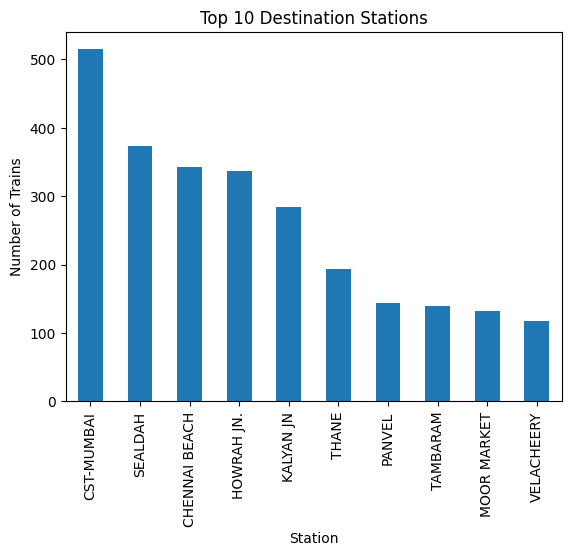

In [29]:
top_dest = df['Destination_Station_Name'].value_counts().head(10)

plt.figure()
top_dest.plot(kind='bar')

plt.title("Top 10 Destination Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")

plt.show()


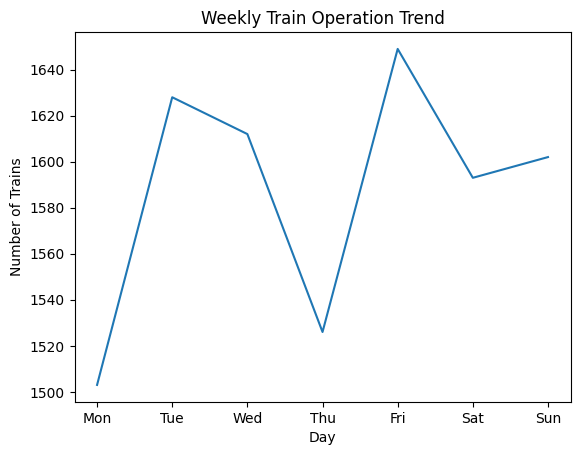

In [30]:
day_counts = df[week_days].sum()

plt.figure()
day_counts.plot(kind='line')

plt.title("Weekly Train Operation Trend")
plt.xlabel("Day")
plt.ylabel("Number of Trains")

plt.show()
